Carregar o Dataset

In [14]:
import kagglehub
import pandas as pd
from kagglehub import KaggleDatasetAdapter
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, ConfusionMatrixDisplay
from imblearn.over_sampling import SMOTE
import os
import numpy as np

# --- Carregamento do Dataset Combinado Diretamente do Kaggle Hub ---
wine_dataset_slug = "ruthgn/wine-quality-data-set-red-white-wine"
wine_file_name = "wine-quality-white-and-red.csv"

# Carrega o arquivo CSV diretamente para um DataFrame do Pandas
df_raw_combined_wine = kagglehub.load_dataset(
    KaggleDatasetAdapter.PANDAS,
    wine_dataset_slug,
    wine_file_name
)

# --- Salvando para Parquet (Boa prática para reusabilidade e performance) ---
output_dir = "data/processed"
os.makedirs(output_dir, exist_ok=True)
parquet_path = os.path.join(output_dir, "wine-quality-combined.parquet")

df_raw_combined_wine.to_parquet(parquet_path, engine="pyarrow", index=False)
print(f"DataFrame salvo com sucesso em formato Parquet: {parquet_path}")

/tmp/ipython-input-14-2451034981.py:19: DeprecationWarning: load_dataset is deprecated and will be removed in a future version.
  df_raw_combined_wine = kagglehub.load_dataset(


DataFrame salvo com sucesso em formato Parquet: data/processed/wine-quality-combined.parquet


Ler o Dataset

In [15]:
df_wine = pd.read_parquet(parquet_path)

print("\n--- Primeiras 5 linhas do DataFrame principal (carregado do Parquet) ---")
print(df_wine.head())

print("\n--- Informações gerais do DataFrame principal ---")
df_wine.info()

print("\n--- Verificando valores ausentes no DataFrame principal ---")
print(df_wine.isnull().sum())


--- Primeiras 5 linhas do DataFrame principal (carregado do Parquet) ---
    type  fixed acidity  volatile acidity  citric acid  residual sugar  \
0  white            7.0              0.27         0.36            20.7   
1  white            6.3              0.30         0.34             1.6   
2  white            8.1              0.28         0.40             6.9   
3  white            7.2              0.23         0.32             8.5   
4  white            7.2              0.23         0.32             8.5   

   chlorides  free sulfur dioxide  total sulfur dioxide  density    pH  \
0      0.045                 45.0                 170.0   1.0010  3.00   
1      0.049                 14.0                 132.0   0.9940  3.30   
2      0.050                 30.0                  97.0   0.9951  3.26   
3      0.058                 47.0                 186.0   0.9956  3.19   
4      0.058                 47.0                 186.0   0.9956  3.19   

   sulphates  alcohol  quality  
0  

In [16]:
df_processed_features = df_wine.copy()
df_processed_features = pd.get_dummies(df_processed_features, columns=['type'], drop_first=True, dtype=int)

print("\n--- Primeiras 5 linhas do DataFrame após One-Hot Encoding de 'type' ---")
print(df_processed_features.head())


--- Primeiras 5 linhas do DataFrame após One-Hot Encoding de 'type' ---
   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.0              0.27         0.36            20.7      0.045   
1            6.3              0.30         0.34             1.6      0.049   
2            8.1              0.28         0.40             6.9      0.050   
3            7.2              0.23         0.32             8.5      0.058   
4            7.2              0.23         0.32             8.5      0.058   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 45.0                 170.0   1.0010  3.00       0.45   
1                 14.0                 132.0   0.9940  3.30       0.49   
2                 30.0                  97.0   0.9951  3.26       0.44   
3                 47.0                 186.0   0.9956  3.19       0.40   
4                 47.0                 186.0   0.9956  3.19       0.40   

   alcohol  q

Divisão binária entre Vinhos bons e Vinhos ruins

In [17]:
df_processed_features['good_quality'] = df_processed_features['quality'].apply(lambda x: 1 if x >= 6 else 0)
features_cols_no_engineering = df_processed_features.drop(['quality', 'good_quality'], axis=1).columns

X = df_processed_features[features_cols_no_engineering].copy()
y = df_processed_features['good_quality']

print(f"\nShape das Features (X) (SEM Engenharia de Features): {X.shape}")


Shape das Features (X) (SEM Engenharia de Features): (6497, 12)


Escalonamento

In [18]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

print("\n--- Primeiras 5 linhas das Features Escalonadas (X_scaled_df) (SEM Engenharia de Features) ---")
print(X_scaled_df.head())
print("\n--- Média e Desvio Padrão das Features Escalonadas (devem ser próximos de 0 e 1) ---")
print(X_scaled_df.describe().loc[['mean', 'std']])


--- Primeiras 5 linhas das Features Escalonadas (X_scaled_df) (SEM Engenharia de Features) ---
   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0      -0.166089         -0.423183     0.284686        3.206929  -0.314975   
1      -0.706073         -0.240949     0.147046       -0.807837  -0.200790   
2       0.682458         -0.362438     0.559966        0.306208  -0.172244   
3      -0.011808         -0.666161     0.009406        0.642523   0.056126   
4      -0.011808         -0.666161     0.009406        0.642523   0.056126   

   free sulfur dioxide  total sulfur dioxide   density        pH  sulphates  \
0             0.815565              0.959976  2.102214 -1.359049  -0.546178   
1            -0.931107              0.287618 -0.232332  0.506915  -0.277351   
2            -0.029599             -0.331660  0.134525  0.258120  -0.613385   
3             0.928254              1.243074  0.301278 -0.177272  -0.882212   
4             0.928254              1.24

Treino e Teste antes do balanceamento

In [19]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled_df, y, test_size=0.2, random_state=42, stratify=y)

print(f"Shape de X_train: {X_train.shape}")
print(f"Shape de X_test: {X_test.shape}")
print(f"Shape de y_train: {y_train.shape}")
print(f"Shape de y_test: {y_test.shape}")

print("\n--- Proporção das classes em y_train (pré-balanceamento) ---")
print(y_train.value_counts(normalize=True))
print("\n--- Proporção das classes em y_test ---")
print(y_test.value_counts(normalize=True))

Shape de X_train: (5197, 12)
Shape de X_test: (1300, 12)
Shape de y_train: (5197,)
Shape de y_test: (1300,)

--- Proporção das classes em y_train (pré-balanceamento) ---
good_quality
1    0.633058
0    0.366942
Name: proportion, dtype: float64

--- Proporção das classes em y_test ---
good_quality
1    0.633077
0    0.366923
Name: proportion, dtype: float64


As células abaixo devem ser rodadas de acordo com o método de balanceamento escolhido (apenas um)

In [ ]:
# (Pro SMOTE):
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)
metodo_balanceamento = 'SMOTE'

In [20]:
# ADASYN
from imblearn.over_sampling import ADASYN
adasyn = ADASYN(random_state=42)
X_train_resampled, y_train_resampled = adasyn.fit_resample(X_train, y_train)

print("\n--- Shape de X_train após ADASYN ---")
print(X_train_resampled.shape)
print("\n--- Contagem de classes em y_train_resampled (após ADASYN) ---")
print(y_train_resampled.value_counts())
metodo_balanceamento = 'ADASYN'


--- Shape de X_train após ADASYN ---
(6478, 12)

--- Contagem de classes em y_train_resampled (após ADASYN) ---
good_quality
1    3290
0    3188
Name: count, dtype: int64


In [ ]:
# (Pro SMOTEENN):
from imblearn.combine import SMOTEENN
smoteenn = SMOTEENN(random_state=42)
X_train_resampled, y_train_resampled = smoteenn.fit_resample(X_train, y_train)

metodo_balanceamento = 'SMOTEENN'

Usar Grid Search para obter os melhores parâmetros

In [21]:
from sklearn.model_selection import GridSearchCV
import xgboost as xgb

xgb_base = xgb.XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    random_state=42
)

param_grid = {
    'n_estimators': [50, 100], # Reduzindo o número de estimadores
    'max_depth': [3, 4],  # Explorando profundidades menores
    'learning_rate': [0.01, 0.05, 0.1], # Explorando learning rates menores
    'subsample': [0.7, 0.8, 0.9], # Explorando subsamples menores
    'colsample_bytree': [0.7, 0.8, 0.9], # Explorando colsample_bytree menores
    'gamma': [0.1, 0.2, 0.3],  # Aumentando gamma
    'reg_alpha': [0.1, 0.5, 1.0],  # Aumentando regularização L1
    'reg_lambda': [0.5, 1.0, 2.0],  # Aumentando regularização L2
    'min_child_weight': [1, 3, 5] # Adicionando min_child_weight
}

grid_search = GridSearchCV(
    estimator=xgb_base,
    param_grid=param_grid,
    scoring='accuracy',
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train_resampled, y_train_resampled)

print("Melhores parâmetros encontrados:")
print(grid_search.best_params_)
print(f"Melhor acurácia CV: {grid_search.best_score_:.4f}")

Fitting 5 folds for each of 8748 candidates, totalling 43740 fits
Melhores parâmetros encontrados:
{'colsample_bytree': 0.8, 'gamma': 0.3, 'learning_rate': 0.1, 'max_depth': 4, 'min_child_weight': 1, 'n_estimators': 100, 'reg_alpha': 0.1, 'reg_lambda': 0.5, 'subsample': 0.9}
Melhor acurácia CV: 0.7780


In [22]:
melhores_params = grid_search.best_params_

xgb_model = xgb.XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    random_state=42,
    **melhores_params
)

xgb_model.fit(X_train_resampled, y_train_resampled)
y_pred_proba = xgb_model.predict_proba(X_test)[:, 1]
y_pred = xgb_model.predict(X_test)

Resultados e Gráficos

In [23]:
from sklearn.metrics import classification_report, accuracy_score
import pandas as pd

def gera_relatorio_completo(modelo, X, y, nome):
    y_pred = modelo.predict(X)
    report = classification_report(y, y_pred, output_dict=True)
    acc = accuracy_score(y, y_pred)

    df_rep = pd.DataFrame(report).T
    df_rep = df_rep.loc[['0', '1', 'macro avg', 'weighted avg'], ['precision','recall','f1-score','support']]
    df_rep.index = ['Vinhos Ruins','Vinhos Bons','Média Simples','Média Ponderada']
    df_rep = df_rep.round(4)

    print(f"\n Relatório do conjunto {nome} utilizando {metodo_balanceamento}:")
    display(df_rep)
    print(f"Acurácia {nome}: {acc:.4f}\n")

gera_relatorio_completo(xgb_model, X_train_resampled, y_train_resampled, 'Treino')

gera_relatorio_completo(xgb_model, X_test, y_test, 'Teste')


 Relatório do conjunto Treino utilizando ADASYN:


,precision,recall,f1-score,support
Vinhos Ruins,0.8099,0.8604,0.8344,3188.0
Vinhos Bons,0.8560,0.8043,0.8293,3290.0
Média Simples,0.8329,0.8323,0.8319,6478.0
Média Ponderada,0.8333,0.8319,0.8318,6478.0


Acurácia Treino: 0.8319


 Relatório do conjunto Teste utilizando ADASYN:


,precision,recall,f1-score,support
Vinhos Ruins,0.6612,0.7568,0.7058,477.0
Vinhos Bons,0.8462,0.7752,0.8091,823.0
Média Simples,0.7537,0.7660,0.7574,1300.0
Média Ponderada,0.7783,0.7685,0.7712,1300.0


Acurácia Teste: 0.7685



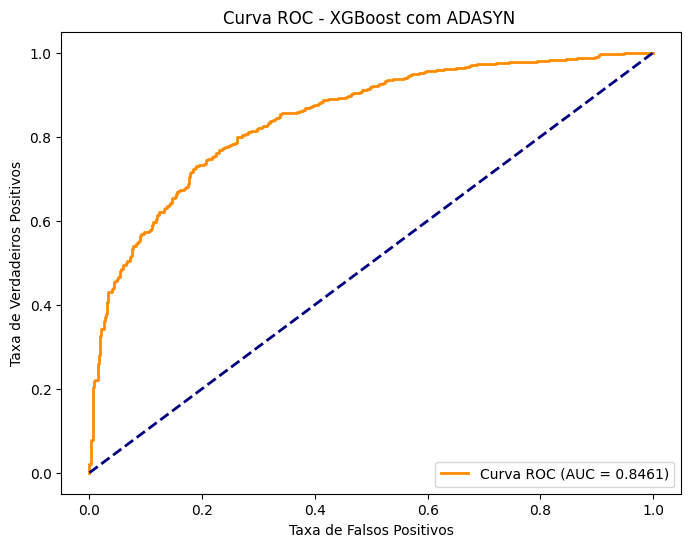

In [24]:
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = roc_auc_score(y_test, y_pred_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Curva ROC (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('Taxa de Falsos Positivos')
plt.ylabel('Taxa de Verdadeiros Positivos')
plt.title(f'Curva ROC - XGBoost com {metodo_balanceamento} ')
plt.legend(loc="lower right")
plt.show()

<Figure size 1200x800 with 0 Axes>

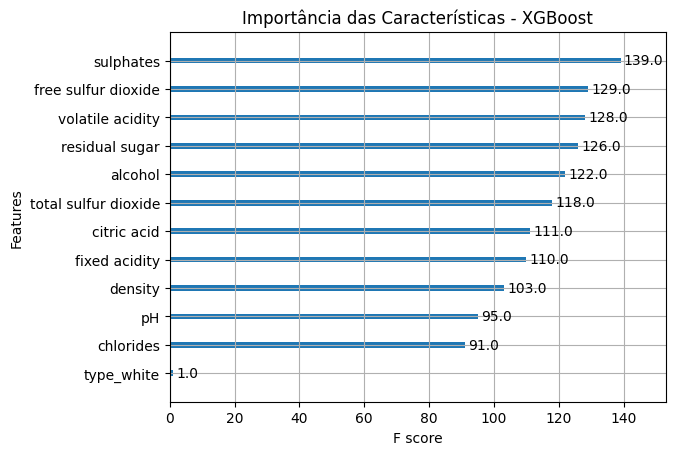

In [25]:
plt.figure(figsize=(12, 8))
xgb.plot_importance(xgb_model, max_num_features=15, importance_type='weight')
plt.title('Importância das Características - XGBoost')
plt.show()

In [26]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print(f"\n--- Resultados Gerais com {metodo_balanceamento} ---")
print(f"Acurácia: {accuracy_score(y_test, y_pred):.4f}")
print(f"Precisão: {precision_score(y_test, y_pred):.4f}")
print(f"Recall: {recall_score(y_test, y_pred):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred):.4f}")
print(f"AUC-ROC: {roc_auc:.4f}")


--- Resultados Gerais com ADASYN ---
Acurácia: 0.7685
Precisão: 0.8462
Recall: 0.7752
F1-Score: 0.8091
AUC-ROC: 0.8461


Salvando o modelo

In [27]:
import joblib
from google.colab import files

joblib.dump(xgb_model, "modelo_xgboost.pkl")
files.download("modelo_xgboost.pkl")
print("Modelo salvo como modelo_xgboost.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Modelo salvo como modelo_xgboost.pkl
